# Plot vowels

Let's use Python to plot our extracted formant vowels and inspect our vowels spaces.
We'll start with a very simple figure, where we simply plot the raw F1 and F2 frequencies for the cardinal vowels.
Things to notice:
1. We need to import libraries
2. We use `pandas` to import and structure our data
3. We use `seaborn` to make plotting easier
4. We use `matplotlib.pyplot` to make adjustments to our figure
5. We rename libraries with abreviations

In [1]:
# import data structuring and plotting libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# quiet warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Read our txt file into a pandas dataframe
df = pd.read_csv('/Users/ethan/Documents/praat_tutorial_tempfiles/h_d_raw/formants/combined_formants.txt', sep='\t')


# inspect the first 5 lines
df

,Interval,Label,Start,End,Duration,F1,F2,F3,Source_File
0,2,Segment_1,0.218,0.530,0.312,244.8,2096.7,2810.6,h_d_AmEng1_formants
1,4,Segment_2,1.098,1.450,0.352,295.4,1998.6,2687.1,h_d_AmEng1_formants
2,6,Segment_3,2.250,2.570,0.320,348.4,1888.2,2692.2,h_d_AmEng1_formants
3,8,Segment_4,3.186,3.546,0.360,466.3,1821.8,2604.2,h_d_AmEng1_formants
4,10,Segment_5,4.162,4.498,0.336,447.5,1293.4,2574.8,h_d_AmEng1_formants
...,...,...,...,...,...,...,...,...,...
67,8,Segment_4,6.441,6.769,0.328,597.1,1488.1,2593.8,h_d_ScEng_formants
68,10,Segment_5,7.785,8.049,0.264,359.4,1180.7,2698.6,h_d_ScEng_formants
69,12,Segment_6,9.073,9.409,0.336,433.7,1365.2,2791.0,h_d_ScEng_formants
70,14,Segment_7,10.417,10.633,0.216,307.7,1658.4,2569.6,h_d_ScEng_formants


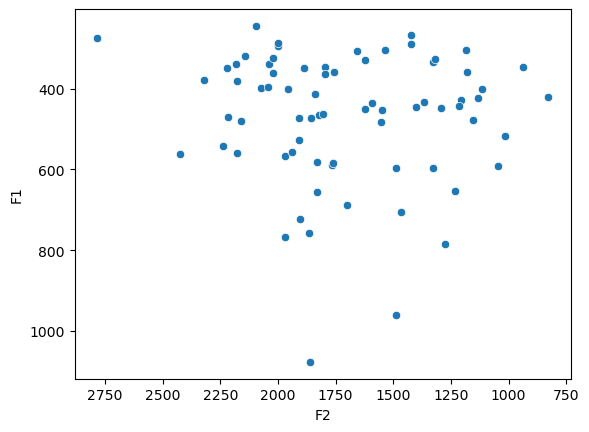

In [3]:
ax = sns.scatterplot(data=df, x=df['F2'], y=df['F1'])
ax.invert_yaxis()
ax.invert_xaxis()

## Fancier vowel plots using helper functions

The vowelplot, barkify, and Lobify functions below were written by [Emily Remirez](https://sites.google.com/berkeley.edu/eremirez/) and copied from: [Linguistics Methods Hub: Vowel plotting in Python](https://lingmethodshub.github.io/content/python/vowel-plotting-py/index.html).

Using Emily's functions, we can quickly and easily make professional-looking vowel plots for comparing speakers, dialects, or languages.


In [4]:
# vowelplot function
# written by Emily Remirez
# small modification to remove left and right spines by Ethan Weed

import matplotlib.pyplot as plt
import pandas as pd
from pandas import DataFrame
import seaborn as sns
import matplotlib.ticker as ticker
from matplotlib.ticker import ScalarFormatter

def vowelplot (vowelcsv, color=None, F1="F1", F2="F2", vowel="Vowel", title="Vowel Plot", unit="Hz", logscale=True):

    #Set some parameters for the chart itself
    sns.set(style='ticks', context='notebook')
    plt.figure(figsize=(6,6))

    # If there's an argument for color, determine whether it's likely to be categorical
    ## If it's a string (text), use a categorical color palette
    ## If it's a number, use a sequential color palette
    if color != None:
        if type(vowelcsv[color].iloc[0])==str:
            pal = "husl"
            #pal = "Dark2"
        else:
            pal = "viridis"

        pl = sns.scatterplot(x = F2,
                             y = F1,
                             hue = color,
                             data = vowelcsv,
                             palette = pal)

    # If no color argument is given, don't specify hue, and no palette needed
    else:
        pl = sns.scatterplot(x = F2,
                             y = F1,
                             data = vowelcsv)


    #Invert axes to correlate with articulatory space!
    pl.invert_yaxis()
    pl.invert_xaxis()

    #Add unit to the axis labels
    F1name = str("F1 ("+unit+")")
    F2name = str("F2 ("+unit+")")
    laby = plt.ylabel(F1name)
    labx = plt.xlabel(F2name)

    if logscale == True:
        pl.loglog()
        pl.yaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.yaxis.set_minor_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_major_formatter(ticker.ScalarFormatter())
        pl.xaxis.set_minor_formatter(ticker.ScalarFormatter())

    # Add vowel labels

    if vowel != None:
        for line,row in vowelcsv.iterrows():
            pl.text(vowelcsv[F2][line]+0.1,
                    vowelcsv[F1][line],
                    vowelcsv[vowel][line],
                    horizontalalignment = 'left',
                    size = 14, # Edit for larger plots!
                    color = 'black',
                   # weight = 'semibold' # Uncomment for larger plots!
                   )

    pl.set_title(title)
    pl.spines['top'].set_visible(False)
    pl.spines['right'].set_visible(False)
    plt.show()

    return pl

In [5]:
# function to convert formants from Hz to bark units
# a bark scale is a better approximation of our nonliear pyschoacoustic perception of the physical sound frequencies

def barkify (data, formants):
    # For each formant listed, make a copy of the column prefixed with z
    for formant in formants:
        for ch in formant:
            if ch.isnumeric():
                num = ch
        formantchar = (formant.split(num)[0])
        name = str(formant).replace(formantchar,'z')
        # Convert each value from Hz to Bark
        data[name] = 26.81/ (1+ 1960/data[formant]) - 0.53
    # Return the dataframe with the changes
    return data

In [6]:
# a function to normalize formants based on each speaker's vowel space, using the Lobanov method.
# for details and descriptions, including pros and cons for each method, as well as an online tool for using the different algorithms, see http://lingtools.uoregon.edu/norm/norm1_methods.php

def Lobify (data, group, formants):
    zscore = lambda x: (x - x.mean()) / x.std()
    for formant in formants:
        name = str("zsc_" + formant)
        col = data.groupby([group])[formant].transform(zscore)
        data.insert(len(data.columns), name, col)
    return data


## Plotting vowel spaces

Let's compare different speakers producing the vowels in English words 'heed', 'hid', 'head', 'had', 'hod', 'hawed', 'hood', and 'who'd'.

<img src="https://kagi.com/proxy/images?c=_m3km2RjA3G0qleowsZXHZb9NEn0fSsEYIHbKzMDyAFb4nUPIanknmQV_g0rmdCIbMWuvyo7994ui97cT-3EedvKHC3hiNCl3h5OMx-XVM9HyXvCWU_IGx_mPDPr1dfEaGFA-mOvqORHh0X-9LrKmg%3D%3D" width="400"/>

image credit: www.phonetics.ucla.edu

<img src="https://kagi.com/proxy/tongue.png?c=VyuR3YRKUClPhyOoIdS04TqljqgBzrKDxski68jlhLPReVad1H0Zm0Kgd4UwEzxC-foBCJc2-1ghyNdX1b6XRg%3D%3D" width="400"/>

image credit: Wilfred Bates



Load the data into a `pandas` dataframe

In [7]:
# load the data into a dataframe
df = pd.read_csv('/Users/ethan/Documents/praat_tutorial_tempfiles/h_d_raw/formants/combined_formants.txt', sep='\t')

#labels = ['heed', 'hid', 'head', 'had', 'hod', 'hawed', 'hood', 'whod']
labels = ['i', 'I', 'ɛ', 'æ', 'ɑ', 'ɔ', 'ʊ', 'u']

# Make a new column called speaker with the string bewten "h_d_" and "_formants" in Source_File
df['Speaker'] = df['Source_File'].str.extract(r'(h_d_)(.*)(_formants)')[1]

label_dict = {
    'Segment_1': 'i',
    'Segment_2': 'I',
    'Segment_3': 'ɛ',
    'Segment_4': 'æ',
    'Segment_5': 'ɑ',
    'Segment_6': 'ɔ',
    'Segment_7': 'ʊ',
    'Segment_8': 'u'
}

# Make a column called vowel. Look up the key in the Label column and return the value from the label_dict
df['Vowel'] = df['Label'].map(label_dict)

# Make a new column called dialect with the string in speaker removing any numbers
df['Dialect'] = df['Speaker'].str.extract(r'([a-zA-Z]+)')[0]

df
 

,Interval,Label,Start,End,Duration,F1,F2,F3,Source_File,Speaker,Vowel,Dialect
0,2,Segment_1,0.218,0.530,0.312,244.8,2096.7,2810.6,h_d_AmEng1_formants,AmEng1,i,AmEng
1,4,Segment_2,1.098,1.450,0.352,295.4,1998.6,2687.1,h_d_AmEng1_formants,AmEng1,I,AmEng
2,6,Segment_3,2.250,2.570,0.320,348.4,1888.2,2692.2,h_d_AmEng1_formants,AmEng1,ɛ,AmEng
3,8,Segment_4,3.186,3.546,0.360,466.3,1821.8,2604.2,h_d_AmEng1_formants,AmEng1,æ,AmEng
4,10,Segment_5,4.162,4.498,0.336,447.5,1293.4,2574.8,h_d_AmEng1_formants,AmEng1,ɑ,AmEng
...,...,...,...,...,...,...,...,...,...,...,...,...
67,8,Segment_4,6.441,6.769,0.328,597.1,1488.1,2593.8,h_d_ScEng_formants,ScEng,æ,ScEng
68,10,Segment_5,7.785,8.049,0.264,359.4,1180.7,2698.6,h_d_ScEng_formants,ScEng,ɑ,ScEng
69,12,Segment_6,9.073,9.409,0.336,433.7,1365.2,2791.0,h_d_ScEng_formants,ScEng,ɔ,ScEng
70,14,Segment_7,10.417,10.633,0.216,307.7,1658.4,2569.6,h_d_ScEng_formants,ScEng,ʊ,ScEng


In [8]:


# a bit of tidying up....

# list of the words, in the order that matches the data
#labels = ['heed', 'hid', 'head', 'had', 'hod', 'hawed', 'hood', 'whod']
#labels = ['i', 'I', 'ɛ', 'æ', 'ɑ', 'ɔ', 'ʊ', 'u']

#df['Speaker'] = [x[0:6] for x in list(df['Vowel'])]
#df['Language'] = [x[0:5] for x in list(df['Vowel'])]
#df['Vowel'] = labels * int(df.shape[0]/8)
#df

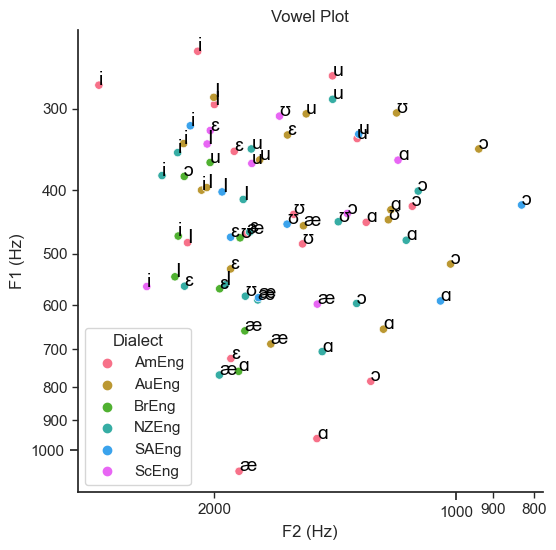

<Axes: title={'center': 'Vowel Plot'}, xlabel='F2 (Hz)', ylabel='F1 (Hz)'>

In [9]:
vowelplot(df, color = 'Dialect')

In [10]:
barkify(df, ["F1","F2"])

,Interval,Label,Start,End,Duration,F1,F2,F3,Source_File,Speaker,Vowel,Dialect,z1,z2
0,2,Segment_1,0.218,0.530,0.312,244.8,2096.7,2810.6,h_d_AmEng1_formants,AmEng1,i,AmEng,2.446727,13.326713
1,4,Segment_2,1.098,1.450,0.352,295.4,1998.6,2687.1,h_d_AmEng1_formants,AmEng1,I,AmEng,2.981428,13.005711
2,6,Segment_3,2.250,2.570,0.320,348.4,1888.2,2692.2,h_d_AmEng1_formants,AmEng1,ɛ,AmEng,3.516354,12.624889
3,8,Segment_4,3.186,3.546,0.360,466.3,1821.8,2604.2,h_d_AmEng1_formants,AmEng1,æ,AmEng,4.622497,12.385135
4,10,Segment_5,4.162,4.498,0.336,447.5,1293.4,2574.8,h_d_AmEng1_formants,AmEng1,ɑ,AmEng,4.453375,10.128405
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,8,Segment_4,6.441,6.769,0.328,597.1,1488.1,2593.8,h_d_ScEng_formants,ScEng,æ,ScEng,5.730315,11.040419
68,10,Segment_5,7.785,8.049,0.264,359.4,1180.7,2698.6,h_d_ScEng_formants,ScEng,ɑ,ScEng,3.624313,9.548825
69,12,Segment_6,9.073,9.409,0.336,433.7,1365.2,2791.0,h_d_ScEng_formants,ScEng,ɔ,ScEng,4.327541,10.477161
70,14,Segment_7,10.417,10.633,0.216,307.7,1658.4,2569.6,h_d_ScEng_formants,ScEng,ʊ,ScEng,3.107799,11.757670


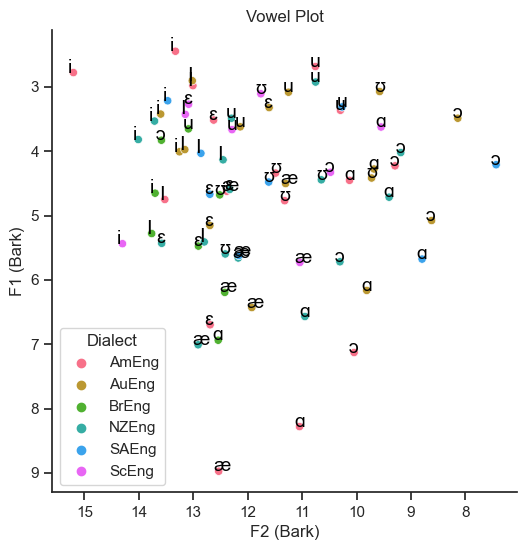

<Axes: title={'center': 'Vowel Plot'}, xlabel='F2 (Bark)', ylabel='F1 (Bark)'>

In [11]:
vowelplot(df,
          F1 = "z1",
          F2 = "z2",
          color = "Dialect",
          unit = "Bark",
          logscale = False)

In [12]:
Lobify(df,
       group = "Speaker",
       formants = ["F1","F2"]
      )

,Interval,Label,Start,End,Duration,F1,F2,F3,Source_File,Speaker,Vowel,Dialect,z1,z2,zsc_F1,zsc_F2
0,2,Segment_1,0.218,0.530,0.312,244.8,2096.7,2810.6,h_d_AmEng1_formants,AmEng1,i,AmEng,2.446727,13.326713,-1.372737,1.260466
1,4,Segment_2,1.098,1.450,0.352,295.4,1998.6,2687.1,h_d_AmEng1_formants,AmEng1,I,AmEng,2.981428,13.005711,-0.799276,0.979806
2,6,Segment_3,2.250,2.570,0.320,348.4,1888.2,2692.2,h_d_AmEng1_formants,AmEng1,ɛ,AmEng,3.516354,12.624889,-0.198615,0.663956
3,8,Segment_4,3.186,3.546,0.360,466.3,1821.8,2604.2,h_d_AmEng1_formants,AmEng1,æ,AmEng,4.622497,12.385135,1.137573,0.473989
4,10,Segment_5,4.162,4.498,0.336,447.5,1293.4,2574.8,h_d_AmEng1_formants,AmEng1,ɑ,AmEng,4.453375,10.128405,0.924508,-1.037740
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,8,Segment_4,6.441,6.769,0.328,597.1,1488.1,2593.8,h_d_ScEng_formants,ScEng,æ,ScEng,5.730315,11.040419,1.681138,-0.634368
68,10,Segment_5,7.785,8.049,0.264,359.4,1180.7,2698.6,h_d_ScEng_formants,ScEng,ɑ,ScEng,3.624313,9.548825,-0.463105,-1.387174
69,12,Segment_6,9.073,9.409,0.336,433.7,1365.2,2791.0,h_d_ScEng_formants,ScEng,ɔ,ScEng,4.327541,10.477161,0.207140,-0.935344
70,14,Segment_7,10.417,10.633,0.216,307.7,1658.4,2569.6,h_d_ScEng_formants,ScEng,ʊ,ScEng,3.107799,11.757670,-0.929480,-0.217313


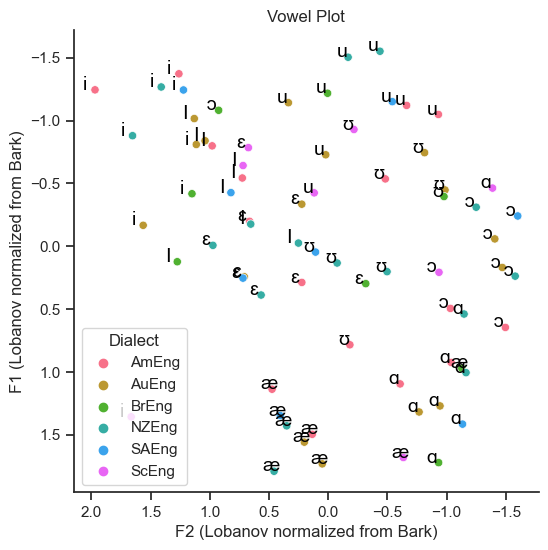

<Axes: title={'center': 'Vowel Plot'}, xlabel='F2 (Lobanov normalized from Bark)', ylabel='F1 (Lobanov normalized from Bark)'>

In [13]:
vowelplot(df,
          F1 = "zsc_F1",
          F2 = "zsc_F2",
          color = "Dialect",
          unit = "Lobanov normalized from Bark",
          logscale = False)

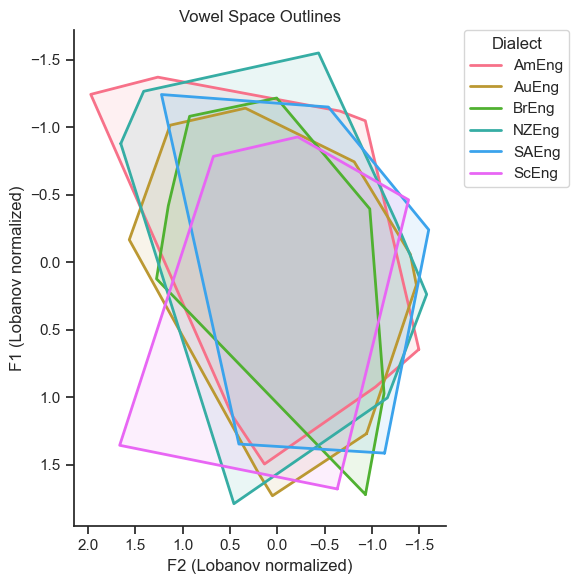

In [17]:
# Draw convex hull outlines around each dialect's vowel space
from scipy.spatial import ConvexHull
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_vowel_space_outlines(data, F1="F1", F2="F2", dialect_col="Dialect",
                               title="Vowel Space Outlines", unit="Hz",
                               logscale=False):
    sns.set(style='ticks', context='notebook')
    fig, ax = plt.subplots(figsize=(6, 6))

    # Use the same husl palette as vowelplot()
    dialects = data[dialect_col].unique()
    palette = sns.color_palette("husl", len(dialects))
    color_map = dict(zip(dialects, palette))

    for dialect in dialects:
        subset = data[data[dialect_col] == dialect][[F2, F1]].dropna()

        # Need at least 3 points to form a hull
        if len(subset) < 3:
            continue

        points = subset.values  # columns: [F2, F1]
        hull = ConvexHull(points)
        color = color_map[dialect]

        # Close the hull by repeating the first vertex
        hull_pts = np.append(hull.vertices, hull.vertices[0])
        ax.plot(points[hull_pts, 0], points[hull_pts, 1],
                color=color, linewidth=2, label=dialect)
        ax.fill(points[hull.vertices, 0], points[hull.vertices, 1],
                alpha=0.1, color=color)

    # Invert axes to match articulatory space
    ax.invert_xaxis()
    ax.invert_yaxis()

    if logscale:
        ax.set_xscale('log')
        ax.set_yscale('log')
        from matplotlib.ticker import ScalarFormatter
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())

    ax.set_xlabel(f"F2 ({unit})")
    ax.set_ylabel(f"F1 ({unit})")
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title=dialect_col, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()


# --- Call the function ---
# For raw Hz formants:
#plot_vowel_space_outlines(df, F1="F1", F2="F2", unit="Hz", logscale=True)

# For Bark-scaled formants (run barkify first):
# plot_vowel_space_outlines(df, F1="z1", F2="z2", unit="Bark")

# For Lobanov-normalized formants (run Lobify first):
plot_vowel_space_outlines(df, F1="zsc_F1", F2="zsc_F2", unit="Lobanov normalized")


In [26]:
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon
import numpy as np
import pandas as pd
import itertools

def compute_vowel_space_overlap(data, F1="F1", F2="F2", dialect_col="Dialect"):
    """
    Computes pairwise Jaccard similarity (Intersection over Union) between
    dialect vowel spaces defined by their convex hulls.
    Returns a symmetric DataFrame of similarity scores.
    """
    dialects = data[dialect_col].unique()
    hulls = {}

    # Build a Shapely Polygon from each dialect's convex hull
    for dialect in dialects:
        subset = data[data[dialect_col] == dialect][[F2, F1]].dropna()
        if len(subset) < 3:
            print(f"Skipping '{dialect}': fewer than 3 points.")
            continue
        points = subset.values  # [F2, F1]
        hull = ConvexHull(points)
        hull_polygon = Polygon(points[hull.vertices])
        hulls[dialect] = hull_polygon

    # Compute pairwise Jaccard index (Intersection over Union)
    dialect_names = list(hulls.keys())
    results = pd.DataFrame(index=dialect_names, columns=dialect_names, dtype=float)

    for d1, d2 in itertools.product(dialect_names, repeat=2):
        if d1 == d2:
            results.loc[d1, d2] = 1.0
        else:
            poly1, poly2 = hulls[d1], hulls[d2]
            intersection_area = poly1.intersection(poly2).area
            union_area = poly1.union(poly2).area
            jaccard = intersection_area / union_area if union_area > 0 else 0.0
            results.loc[d1, d2] = round(jaccard, 4)

    return results

# --- Run on raw Hz formants ---
#overlap_df = compute_vowel_space_overlap(df, F1="F1", F2="F2")
#print("Pairwise Vowel Space Similarity (Jaccard / IoU):")
#print(overlap_df.to_string())

# --- Run on Bark formants ---
overlap_df = compute_vowel_space_overlap(df, F1="z1", F2="z2")
print("Pairwise Vowel Space Similarity (Jaccard / IoU):")
print(overlap_df.to_string())


# --- Run on Lobanov normalized formants ---
#overlap_df = compute_vowel_space_overlap(df, F1="zsc_F1", F2="zsc_F2")
#print("Pairwise Vowel Space Similarity (Jaccard / IoU):")
#print(overlap_df.to_string())



Pairwise Vowel Space Similarity (Jaccard / IoU):
        AmEng   AuEng   BrEng   NZEng   SAEng   ScEng
AmEng  1.0000  0.3997  0.1127  0.5358  0.2859  0.3389
AuEng  0.3997  1.0000  0.0376  0.5618  0.6537  0.4392
BrEng  0.1127  0.0376  1.0000  0.2018  0.0150  0.2016
NZEng  0.5358  0.5618  0.2018  1.0000  0.4614  0.5734
SAEng  0.2859  0.6537  0.0150  0.4614  1.0000  0.4689
ScEng  0.3389  0.4392  0.2016  0.5734  0.4689  1.0000


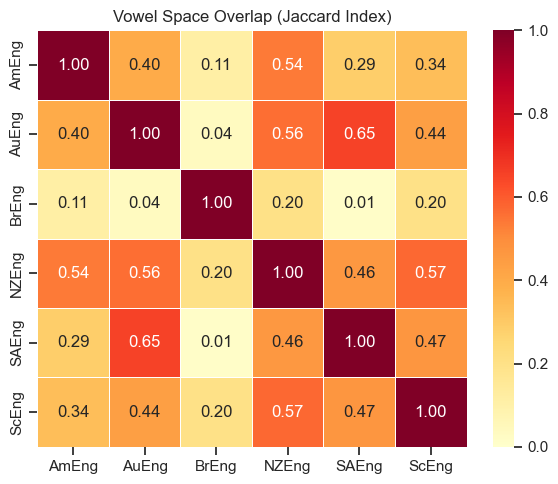

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(overlap_df.astype(float), annot=True, fmt=".2f",
            cmap="YlOrRd", vmin=0, vmax=1,
            linewidths=0.5, ax=ax)
ax.set_title("Vowel Space Overlap (Jaccard Index)")
plt.tight_layout()
plt.show()


In [40]:
from scipy.spatial import ConvexHull
from shapely.geometry import Polygon, Point
import numpy as np
import pandas as pd
import itertools
import matplotlib.pyplot as plt
import seaborn as sns


def classify_new_speaker(reference_data, new_speaker_data,
                          dialect_col="Dialect",
                          speaker_name="New speaker",
                          unit="Hz",                  # "Hz" or "Bark"
                          title=None,
                          logscale=False):

    # Automatically set F1/F2 column names based on unit
    unit_map = {
        "Hz"  : ("F1", "F2"),
        "Bark": ("z1", "z2"),
    }
    if unit not in unit_map:
        raise ValueError(f"unit must be one of {list(unit_map.keys())}, got '{unit}'")

    F1, F2 = unit_map[unit]

    # Auto-generate title if not provided
    if title is None:
        title = f"Vowel Space Classification — {speaker_name}"
    """
    Plots dialect convex hull outlines, overlays new speaker data,
    and ranks which dialect the new speaker most closely resembles.

    Parameters
    ----------
    reference_data   : DataFrame containing the reference dialect data
    new_speaker_data : DataFrame containing the new speaker's formant data
                       (must have the same F1/F2 column names)
    F1, F2           : column names for F1 and F2 formants
    dialect_col      : column name for the dialect grouping variable
    title            : plot title
    unit             : axis label unit string
    logscale         : whether to use log scale on axes
    """


    # ── 1. Build convex hull polygons for each dialect ──────────────────────
    dialects = reference_data[dialect_col].unique()
    palette  = sns.color_palette("husl", len(dialects))
    color_map = dict(zip(dialects, palette))
    hulls = {}

    for dialect in dialects:
        subset = reference_data[reference_data[dialect_col] == dialect][[F2, F1]].dropna()
        if len(subset) < 3:
            print(f"Skipping '{dialect}': fewer than 3 points.")
            continue
        points = subset.values
        hull   = ConvexHull(points)
        hulls[dialect] = Polygon(points[hull.vertices])

    # ── 2. Build the new speaker's convex hull ───────────────────────────────
    new_points = new_speaker_data[[F2, F1]].dropna().values
    if len(new_points) >= 3:
        new_hull    = ConvexHull(new_points)
        new_polygon = Polygon(new_points[new_hull.vertices])
    else:
        new_polygon = None
        print("Warning: new speaker has fewer than 3 points — hull outline skipped.")

    # ── 3. Plot ──────────────────────────────────────────────────────────────
    sns.set(style='ticks', context='notebook')
    fig, ax = plt.subplots(figsize=(7, 7))

    # Reference dialect hulls
    for dialect, poly in hulls.items():
        color = color_map[dialect]
        xs, ys = poly.exterior.xy
        ax.plot(xs, ys, color=color, linewidth=2, label=dialect)
        ax.fill(xs, ys, alpha=0.1, color=color)

    # New speaker: individual points
    ax.scatter(new_points[:, 0], new_points[:, 1],
               color='black', zorder=5, s=60, marker='x',
               label=speaker_name)

    # New speaker: hull outline (if enough points)
    if new_polygon:
        xs, ys = new_polygon.exterior.xy
        ax.plot(xs, ys, color='black', linewidth=2,
                linestyle='--', label=f"{speaker_name}'s vowel space")

    ax.invert_xaxis()
    ax.invert_yaxis()

    if logscale:
        ax.set_xscale('log')
        ax.set_yscale('log')
        from matplotlib.ticker import ScalarFormatter
        ax.xaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_major_formatter(ScalarFormatter())

    ax.set_xlabel(f"F2 ({unit})")
    ax.set_ylabel(f"F1 ({unit})")
    ax.set_title(title)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(title="Dialect", bbox_to_anchor=(1.05, 1),
              loc='upper left', borderaxespad=0)
    plt.tight_layout()
    plt.show()

    # ── 4. Similarity metrics ────────────────────────────────────────────────
    results = []

    for dialect, ref_poly in hulls.items():

        # (a) Jaccard index (IoU) between the two hull polygons
        if new_polygon:
            intersection = new_polygon.intersection(ref_poly).area
            union        = new_polygon.union(ref_poly).area
            jaccard      = intersection / union if union > 0 else 0.0
        else:
            jaccard = np.nan

        # (b) Overlap coefficient: how much of the new speaker's hull
        #     falls inside the reference dialect hull
        if new_polygon and new_polygon.area > 0:
            overlap_coeff = intersection / new_polygon.area
        else:
            overlap_coeff = np.nan

        # (c) Centroid distance: Euclidean distance between hull centroids
        #     (smaller = more similar)
        if new_polygon:
            new_centroid = np.array(new_polygon.centroid.coords[0])
            ref_centroid = np.array(ref_poly.centroid.coords[0])
            centroid_dist = np.linalg.norm(new_centroid - ref_centroid)
        else:
            # Fall back to mean point distance if no hull
            new_mean = new_points.mean(axis=0)
            ref_centroid = np.array(ref_poly.centroid.coords[0])
            centroid_dist = np.linalg.norm(new_mean - ref_centroid)

        # (d) Point containment: proportion of new speaker's individual
        #     vowel tokens that fall inside the reference hull
        n_inside = sum(ref_poly.contains(Point(p)) for p in new_points)
        containment = n_inside / len(new_points)

        results.append({
            "Dialect"          : dialect,
            "Jaccard (IoU)"    : round(jaccard, 4),
            "Overlap coeff."   : round(overlap_coeff, 4),
            "Centroid distance": round(centroid_dist, 2),
            "Point containment": round(containment, 4)
        })

    results_df = (pd.DataFrame(results)
                    .sort_values("Jaccard (IoU)", ascending=False)
                    .reset_index(drop=True))

    print("\n── Dialect similarity ranking ──────────────────────────────")
    print(results_df.to_string(index=False))
    print(f"\n▶  Best match (Jaccard):      {results_df.iloc[0]['Dialect']}")
    print(f"▶  Best match (containment):  "
          f"{results_df.sort_values('Point containment', ascending=False).iloc[0]['Dialect']}")
    print(f"▶  Closest centroid:          "
          f"{results_df.sort_values('Centroid distance').iloc[0]['Dialect']}")

    return results_df



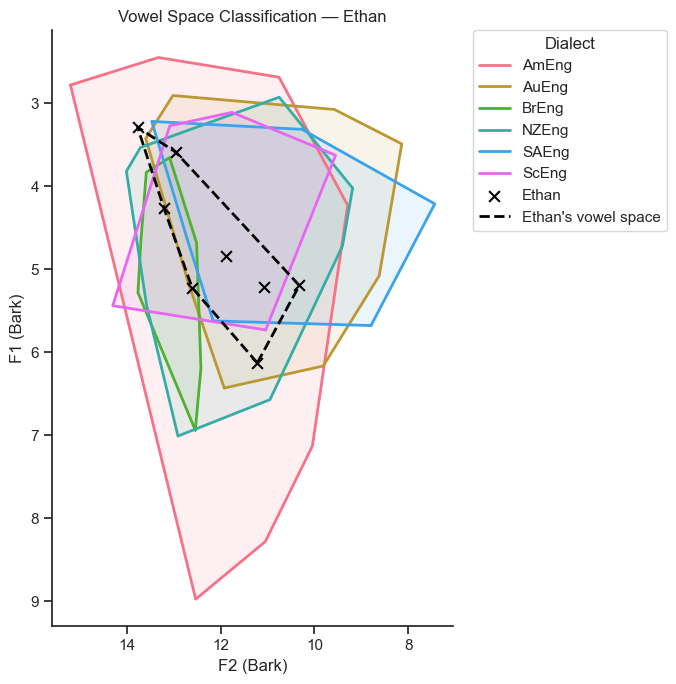


── Dialect similarity ranking ──────────────────────────────
Dialect  Jaccard (IoU)  Overlap coeff.  Centroid distance  Point containment
  ScEng         0.3466          0.8515               0.38              0.625
  NZEng         0.2689          0.9886               0.28              0.875
  AuEng         0.2545          0.9755               1.18              0.750
  SAEng         0.2394          0.7589               1.47              0.500
  AmEng         0.1487          1.0000               0.38              1.000
  BrEng         0.1054          0.1675               1.10              0.250

▶  Best match (Jaccard):      ScEng
▶  Best match (containment):  AmEng
▶  Closest centroid:          NZEng


In [ ]:


new_speaker = '/path/to/your/new speaker/data'
new_speaker = pd.read_csv(new_speaker, sep='\t')
barkify(new_speaker, ["F1", "F2"])



results = classify_new_speaker(
    reference_data   = df,
    new_speaker_data = new_speaker,
    unit  = "Bark",
    logscale = False,
    speaker_name="Ethan")
